In [1]:
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
from torchvision import transforms

import torch
import torch.nn as nn
from tqdm import tqdm
import torch.optim as optim

from dcgan import Generator, Discriminator, weights_init
from pilae_gpu import PILAE

DATASET_DIR = r"C:\Users\adity\OneDrive\Desktop\Desktop\College\Semester 4\Mathematics for Computing 4\Project\Dataset\color"

transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

dataset = ImageFolder(DATASET_DIR, transform=transform)
NUM_CLASSES = len(dataset.classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
from torch.utils.data import Subset
import numpy as np
from collections import defaultdict

MAX_PER_CLASS = 50
TRAIN_SPLIT = 0.6
BATCH_SIZE = 64

np.random.seed(42)

# Collect indices per class
class_indices = defaultdict(list)

for idx in range(len(dataset)):
    _, label = dataset[idx]
    class_indices[int(label)].append(idx)

train_indices = []
test_indices = []

for cls, indices in class_indices.items():
    indices = np.array(indices)
    np.random.shuffle(indices)

    # Downsample to max 50 per class
    selected = indices[:MAX_PER_CLASS]

    split_point = int(TRAIN_SPLIT * len(selected))
    train_indices.extend(selected[:split_point])
    test_indices.extend(selected[split_point:])

train_dataset = Subset(dataset, train_indices)
test_dataset  = Subset(dataset, test_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Balanced train size:", len(train_dataset))
print("Balanced test size :", len(test_dataset))



Balanced train size: 1140
Balanced test size : 760


In [3]:
nz  = 100    
ngf = 64
ndf = 64
nc  = 3

EPOCHS = 50
lr = 0.0002
beta1 = 0.5

netG = Generator(nz, ngf, nc, n_classes=NUM_CLASSES).to(device)
netD = Discriminator(nc, ndf, n_classes=NUM_CLASSES).to(device)

netG.apply(weights_init)
netD.apply(weights_init)

criterion = nn.BCELoss()

optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))


In [4]:
netG.train()
netD.train()

for epoch in range(EPOCHS):
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for imgs, labels in pbar:
        imgs   = imgs.to(device)
        labels = labels.to(device)
        bsz = imgs.size(0)

        # where you create labels for real/fake:
        real = torch.ones(imgs.size(0), device=device)   # shape [batch]
        fake = torch.zeros(imgs.size(0), device=device)  # shape [batch]

        # then
        out_real = netD(imgs, labels)
        loss_real = criterion(out_real.view(-1), real)   # flatten network output to [batch]


        # ---- Train Discriminator ----
        netD.zero_grad()

        out_real = netD(imgs, labels)
        loss_real = criterion(out_real, real)

        noise = torch.randn(bsz, nz, 1, 1, device=device)
        fake_imgs = netG(noise, labels)

        out_fake = netD(fake_imgs.detach(), labels)
        loss_fake = criterion(out_fake, fake)

        d_loss = loss_real + loss_fake
        d_loss.backward()
        optimizerD.step()

        # ---- Train Generator ----
        netG.zero_grad()

        out_fake = netD(fake_imgs, labels)
        g_loss = criterion(out_fake, real)

        g_loss.backward()
        optimizerG.step()

        pbar.set_postfix({
            "D_loss": d_loss.item(),
            "G_loss": g_loss.item()
        })

for p in netD.parameters():
    p.requires_grad = False

netD.eval()


Epoch 50/50: 100%|██████████| 18/18 [00:01<00:00, 12.60it/s, D_loss=1.04, G_loss=1.18] 


Discriminator(
  (main): Sequential(
    (0): Conv2d(41, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (final): Sequential(
    (0): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): Sigmoid()
  )
)

In [5]:

def extract_features(loader):
    X, y = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(device)
            labels = labels.to(device)
            feats = netD.extract_features(imgs, labels)
            X.append(feats.cpu())
            y.append(labels.cpu())
    return torch.cat(X), torch.cat(y)


In [6]:
# --- Augment PILAE training with DCGAN-generated images ---
# Tune this if you want more/less synthetic data
SYN_PER_CLASS = 50

netG.eval()

with torch.no_grad():
    # Create labels like 0..NUM_CLASSES-1, repeated
    syn_labels = torch.arange(NUM_CLASSES, device=device).repeat_interleave(SYN_PER_CLASS)
    syn_labels = syn_labels[:NUM_CLASSES * SYN_PER_CLASS]

    noise = torch.randn(syn_labels.size(0), nz, 1, 1, device=device)
    syn_imgs = netG(noise, syn_labels)

    # Extract features using the trained discriminator
    syn_feats = netD.extract_features(syn_imgs, syn_labels).cpu()
    syn_labels_cpu = syn_labels.cpu()

# Combine real + synthetic features for PILAE training
X_train_syn = syn_feats
y_train_syn = syn_labels_cpu

print('Synthetic features:', X_train_syn.shape)

# Note: X_train / y_train are created in the next cell; we will augment there.


Synthetic features: torch.Size([1900, 8192])


In [7]:
X_train, y_train = extract_features(train_loader)
X_test,  y_test  = extract_features(test_loader)

# If synthetic features were created, append them to the training set
if 'X_train_syn' in globals():
    X_train = torch.cat([X_train, X_train_syn], dim=0)
    y_train = torch.cat([y_train, y_train_syn], dim=0)

print('Train features:', X_train.shape)
print('Test features :', X_test.shape)


Train features: torch.Size([3040, 8192])
Test features : torch.Size([760, 8192])


In [8]:
from sklearn.preprocessing import OneHotEncoder

# X_train: (N, 8192) DCGAN features
# y_train: (N,) integer labels

enc = OneHotEncoder(sparse_output=False)
Y_train_oh = enc.fit_transform(y_train.reshape(-1, 1))

pilae = PILAE(beta=0.4, reg=1e-2)
pilae.fit(X_train, Y_train_oh)

y_pred = pilae.predict(X_test)


PILAE-GPU fit: X=torch.Size([3040, 8192]), Y=torch.Size([3040, 38]), device=cuda
Computing SVD (this is the expensive step)...
Using truncated rank p=3040
Solving regularized normal equations on GPU...


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")


Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000


Confusion Matrix:
 [[20  0  0 ...  0  0  0]
 [ 0 20  0 ...  0  0  0]
 [ 0  0 20 ...  0  0  0]
 ...
 [ 0  0  0 ... 20  0  0]
 [ 0  0  0 ...  0 20  0]
 [ 0  0  0 ...  0  0 20]]


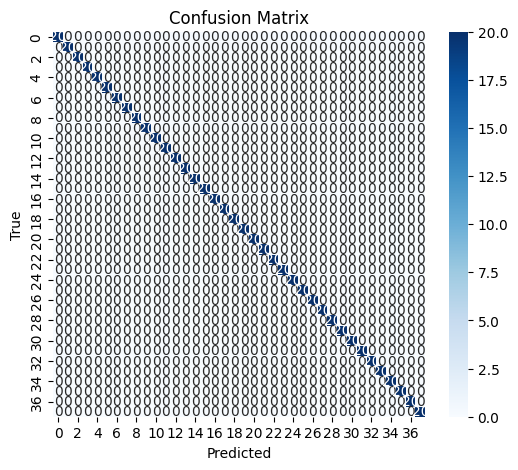

In [10]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()



In [11]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       1.00      1.00      1.00        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       1.00      1.00      1.00        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00        20
          17       1.00    